# BIND — `paint()` walkthrough

This notebook shows the **complete user-facing API** for [BIND](https://github.com/Maxelee/BIND), the flow-matching emulator that paints baryonic fields onto dark-matter-only (DMO) maps.

**The whole API is three things:**

| object | role |
|---|---|
| `bind.Simulation` | DMO particles + halo catalog (load from a Gadget/Arepo HDF5 snapshot or pass arrays) |
| `bind.Model`      | Trained checkpoint + normalization stats; runs the flow-matching sampler |
| `bind.paint(sim, model, params, ...)` | One call: project → cutouts → sample → composite → save |

**Native trained scale** (`bind.NATIVE_PIXEL_SIZE_MPCH`, `bind.NATIVE_SLAB_DEPTH_MPCH`):

- pixel size: 50 / 1024 ≈ 0.0488 Mpc/h (~50 kpc/h)
- z-slab depth: 50 Mpc/h
- halo cutout: 128 × 128 px

So a 50 Mpc/h box → 1 slab × 1024², a 200 Mpc/h box → 4 slabs × 4096².


## 0. Setup

Install (editable):

```bash
pip install -e .
```

Download the pretrained weights into `weights/`:

```bash
bind-download-weights              # both releases
bind-download-weights fm_two_head  # just the standard 3-channel model
```

Optional: the [`MAS_library`](https://github.com/franciscovillaescusa/Pylians3) CIC projector if you want to project Gadget particles yourself.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import bind

print("bind", bind.__version__)
print("native pixel = ", bind.NATIVE_PIXEL_SIZE_MPCH, "Mpc/h")
print("native slab  = ", bind.NATIVE_SLAB_DEPTH_MPCH, "Mpc/h")
print("public API   = ", [x for x in bind.__all__ if not x.startswith("_")])

bind 0.1.0
native pixel =  0.048828125 Mpc/h
native slab  =  50.0 Mpc/h
public API   =  ['Simulation', 'Model', 'paint', 'PaintResult', 'extract_halo_cutouts', 'NATIVE_PIXEL_SIZE_MPCH', 'NATIVE_SLAB_DEPTH_MPCH', 'PATCH_PIX', 'PARAM_NAMES', 'N_PARAMS', 'fiducial_params', 'random_params', 'vary_param', 'vary_params', 'param_dataframe']


## 1. The 3-line workflow

This is the entire user story. Point at a DMO snapshot + halo catalog, point at a checkpoint, hand it a 35-dim parameter vector, get back a `PaintResult` with hydro composite maps written to disk.

```python
sim    = bind.Simulation.from_paths(snapshot=..., group_catalog=...)
model  = bind.Model.from_local("weights/fm_two_head")
result = bind.paint(sim, model, params=my_35dim_vector, output_dir="bind_output/run1")
```

Same thing from the shell:

```bash
bind-paint \
    --snapshot       /path/to/snap_090.hdf5 \
    --group_catalog  /path/to/fof_subhalo_tab_090.hdf5 \
    --params         my_params.npy \
    --run_dir        weights/fm_two_head \
    --output_dir     bind_output/run1
```

The rest of this notebook unpacks each layer and shows what you get.


## 2. `bind.Simulation` — a DMO snapshot + halo catalog

A `Simulation` is just a small dataclass holding everything in physical units (Mpc/h, Msun/h):

| field | shape | meaning |
|---|---|---|
| `dmo_positions`   | `(N_part, 3)` | DMO particle positions [Mpc/h] |
| `particle_mass`   | scalar        | per-particle mass [Msun/h] |
| `box_size`        | scalar        | side length [Mpc/h] |
| `halo_positions`  | `(N_halo, 3)` | halo centers [Mpc/h] |
| `halo_masses`     | `(N_halo,)`   | M200c [Msun/h] |
| `halo_r200`       | `(N_halo,)`   | R200c [Mpc/h] (zeros if unknown) |

Two factory constructors — pick whichever matches your data source.


In [2]:
# --- option A: load directly from a Gadget/Arepo HDF5 snapshot + FOF catalog ---
sim = bind.Simulation.from_paths(
    snapshot="/mnt/ceph/users/camels/Sims/IllustrisTNG_DM/L50n512/CV/CV_0/snap_090.hdf5",
    group_catalog="/mnt/ceph/users/camels/FOF_Subfind/IllustrisTNG_DM/L50n512/CV/CV_0/fof_subhalo_tab_090.hdf5",
    halo_mass_min=1e13,    # M200c cut [Msun/h]
)
print(sim)

Simulation(box=50.00 Mpc/h, n_part=134217728, n_halos=45, M_halo_min=1.00e+13 Msun/h)


In [3]:
# --- option B: build from in-memory arrays (any cosmological-sim source) ---
# Stand-in synthetic data; replace with whatever you have.
rng = np.random.default_rng(0)
sim_mem = bind.Simulation.from_arrays(
    dmo_positions=rng.uniform(0, 50.0, size=(200_000, 3)).astype(np.float32),
    particle_mass=1.5e9,                    # Msun/h
    box_size=50.0,                          # Mpc/h
    halo_positions=rng.uniform(0, 50.0, size=(20, 3)).astype(np.float32),
    halo_masses=10**rng.uniform(13, 14.5, size=20).astype(np.float32),
    halo_r200=np.full(20, 0.5, dtype=np.float32),
)
print(sim_mem)
print("filter_halos:", sim_mem.filter_halos(mass_min=2e13))

Simulation(box=50.00 Mpc/h, n_part=200000, n_halos=20, M_halo_min=1.01e+13 Msun/h)
filter_halos: Simulation(box=50.00 Mpc/h, n_part=200000, n_halos=18, M_halo_min=2.16e+13 Msun/h)


slabs shape: (1, 1024, 1024)


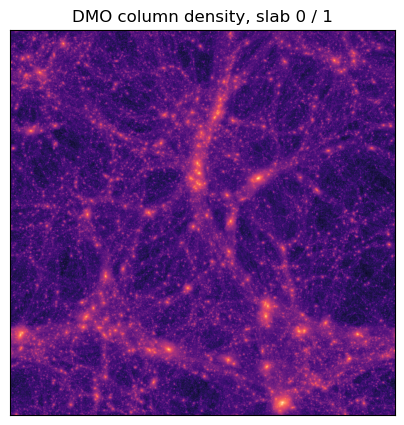

In [4]:
# Project the DMO particles into mass sheets.  Returns (n_slabs, npix, npix).
slabs = sim.project()                     # default: native ~50 kpc/h pixels, 50 Mpc/h slabs
print("slabs shape:", slabs.shape)        # 50 Mpc/h box -> (1, 1024, 1024)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.log10(1 + slabs[0]), origin="lower", cmap="magma")
ax.set_title(f"DMO column density, slab 0 / {slabs.shape[0]}")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 3. `bind.Model` — a loaded checkpoint

The cleanest path is `bind.Model.from_local("weights/<run>")`, which expects the directory layout produced by `bind-download-weights`:

```
weights/fm_two_head/
    last.ckpt
    norm_stats.npz
```

Use `from_files(...)` if your paths don't match that convention.


In [5]:
model = bind.Model.from_local("../weights/fm_two_head", device="auto")
print(model)

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Model(n_params=35, no_large_scale=False, device=cuda)


## 4. `bind.paint(sim, model, params, ...)` — one call

The 35-dim `params` vector is the cosmology + astrophysics conditioning vector that the model was trained against (CAMELS SB35 ordering). Names, fiducial values, prior ranges, and log-sampling flags ship with the package in `src/bind/assets/SB35_param_minmax.csv`. Three helpers cover the common use cases:

- `bind.fiducial_params()` — the fiducial CAMELS-IllustrisTNG vector.
- `bind.random_params(n, rng=...)` — uniform sample(s) from the prior box (log10-uniform for parameters with `LogFlag == 1`).
- `bind.vary_param(name, value=...)` or `bind.vary_param(name, fraction=...)` — fiducial vector with a single parameter overridden.

Inspect the table with `bind.param_dataframe()`. For a CAMELS sim you can also read the parameters straight from the `CosmoAstroSeed_*.txt` file.


In [6]:
# Inspect the parameter table that ships with the package.
df = bind.param_dataframe()
print(df.shape, "params total")
df.head(8)

(35, 7) params total


,ParamName,AbsMaxDiff,LogFlag,FiducialVal,MinVal,MaxVal,Description
0,Omega0,0.20,0,0.3000,0.1000,0.5000,OmegaMatter
1,sigma8,0.20,0,0.8000,0.6000,1.0000,sigma8
2,WindEnergyIn1e51erg,4.00,1,3.6000,0.9000,14.4000,ASN1 - galactic winds energy
3,RadioFeedbackFactor,4.00,1,1.0000,0.2500,4.0000,AAGN1 - AGN FB kinetic mode energy
4,VariableWindVelFactor,2.00,1,7.4000,3.7000,14.8000,ASN2 - galactic winds speed
5,RadioFeedbackReiorientationFactor,2.00,1,20.0000,10.0000,40.0000,AAGN2 - AGN FB kinetic mode burstiness
6,OmegaBaryon,0.02,0,0.0490,0.0290,0.0690,OmegaBaryon
7,HubbleParam,0.20,0,0.6711,0.4711,0.8711,Hubble parameter


In [7]:
# Three ways to build a parameter vector --------------------------------------
fid    = bind.fiducial_params()                 # CAMELS-TNG fiducial
random = bind.random_params(n=4, rng=0)         # 4 random draws from the prior
hi_AGN = bind.vary_param("RadioFeedbackFactor", fraction=1.0)   # fiducial but max AGN1
print("fiducial:           ", fid[:5], "...")
print("random sample 0:    ", random[0, :5], "...")
print("hi-AGN Omega0 same =", hi_AGN[0], " RadioFeedbackFactor =", hi_AGN[3])

fiducial:            [0.3 0.8 3.6 1.  7.4] ...
random sample 0:     [ 0.35478467  0.70791469  1.00827628  0.26172262 11.42455249] ...
hi-AGN Omega0 same = 0.3  RadioFeedbackFactor = 4.0


In [8]:
# CAMELS CV_0 parameter vector
params = np.loadtxt(
    "/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/CV/CosmoAstroSeed_IllustrisTNG_L50n512_CV.txt",
    skiprows=1, usecols=range(1, 36),
)[0]
print("params shape:", params.shape, "(35-dim)")

params shape: (35,) (35-dim)


In [ ]:
result = bind.paint(
    sim, model,
    params=params,
    output_dir="bind_output/cv0_demo",
    n_steps=50,            # flow-matching ODE steps
    batch_size=16,
    # Geometry: defaults match the trained scale; override only if you must.
    # pixel_size=bind.NATIVE_PIXEL_SIZE_MPCH,
    # slab_depth=bind.NATIVE_SLAB_DEPTH_MPCH,
    # Compositing knobs:
    patch_mass_match=True,
    taper_frac=0.15,
    r200_factor=0.0,       # 0 = square taper; >0 = circular paste at r200_factor * R200c
)
print(result)

[paint] box=50.00 Mpc/h, npix=1024, n_slabs=1
[paint] 45 halos, 134217728 particles
[paint] projecting DMO into 1 z-slab(s)...


Generating hydro:  33%|███▎      | 1/3 [00:05<00:10,  5.25s/it]

keys: ['dmo', 'composite', 'alpha', 'patch_scales', 'scale_global', 'coverage_pct', 'n_halos', 'slab_idx', 'n_slabs', 'box_size', 'halo_centers', 'halo_masses', 'halo_r200', 'generated_patches']


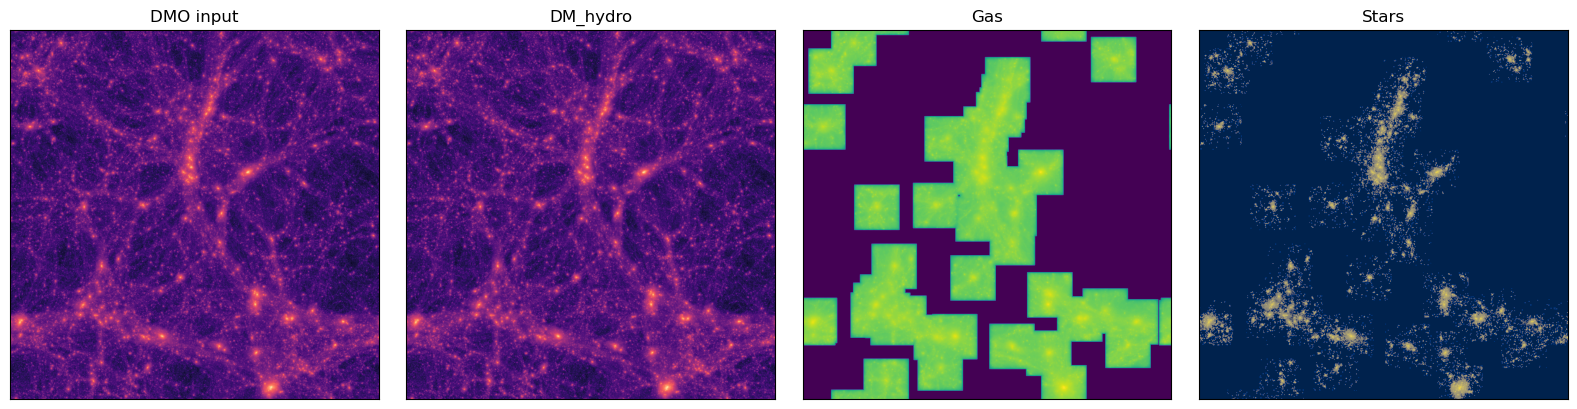

In [9]:
# Inspect the per-slab outputs that paint() writes to disk.
out = np.load(result.composite_paths[0])
print("keys:", list(out.keys()))
dmo = out["dmo"]
composite = out["composite"]      # (3, npix, npix) -> [DM_hydro, Gas, Stars]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title, cmap in zip(
    axes,
    [dmo, composite[0], composite[1], composite[2]],
    ["DMO input", "DM_hydro", "Gas", "Stars"],
    ["magma", "magma", "viridis", "cividis"],
):
    ax.imshow(np.log10(1 + img), origin="lower", cmap=cmap)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 5. Power-user path — step-by-step

`paint()` is a thin orchestrator. Every step is exposed so you can replace, inspect, or batch them yourself:

| step | call |
|---|---|
| project DMO into z-slabs | `slabs = sim.project()` |
| pick halos in a slab     | `idx = sim.slab_assignment()` |
| extract per-halo cutouts | `bind.extract_halo_cutouts(slab, halo_xy, box_size=...)` |
| run the sampler          | `model.generate(cutouts, params, n_steps=...)` |
| paste back into a map    | `bind.inference.pipeline.build_bind_composite(...)` |


In [10]:
# Run the model on the 5 most massive halos by hand, no I/O.
slabs = sim.project()
slab0 = slabs[0]

top5 = np.argsort(sim.halo_masses)[::-1][:5]
xy = sim.halo_positions[top5, :2]

cutouts = bind.extract_halo_cutouts(slab0, xy, box_size=sim.box_size)
print("cutout keys:", list(cutouts[0].keys()),
      "condition:", cutouts[0]["condition"].shape,
      "large_scale:", cutouts[0]["large_scale"].shape)

hydro_patches = model.generate(cutouts, params, n_steps=50, batch_size=8)
print("hydro_patches:", hydro_patches.shape, "(N, [DM, Gas, Stars], H, W)")

cutout keys: ['condition', 'large_scale'] condition: (128, 128) large_scale: (3, 128, 128)


Generating hydro: 100%|██████████| 1/1 [00:01<00:00,  1.99s/it]

hydro_patches: (5, 3, 128, 128) (N, [DM, Gas, Stars], H, W)


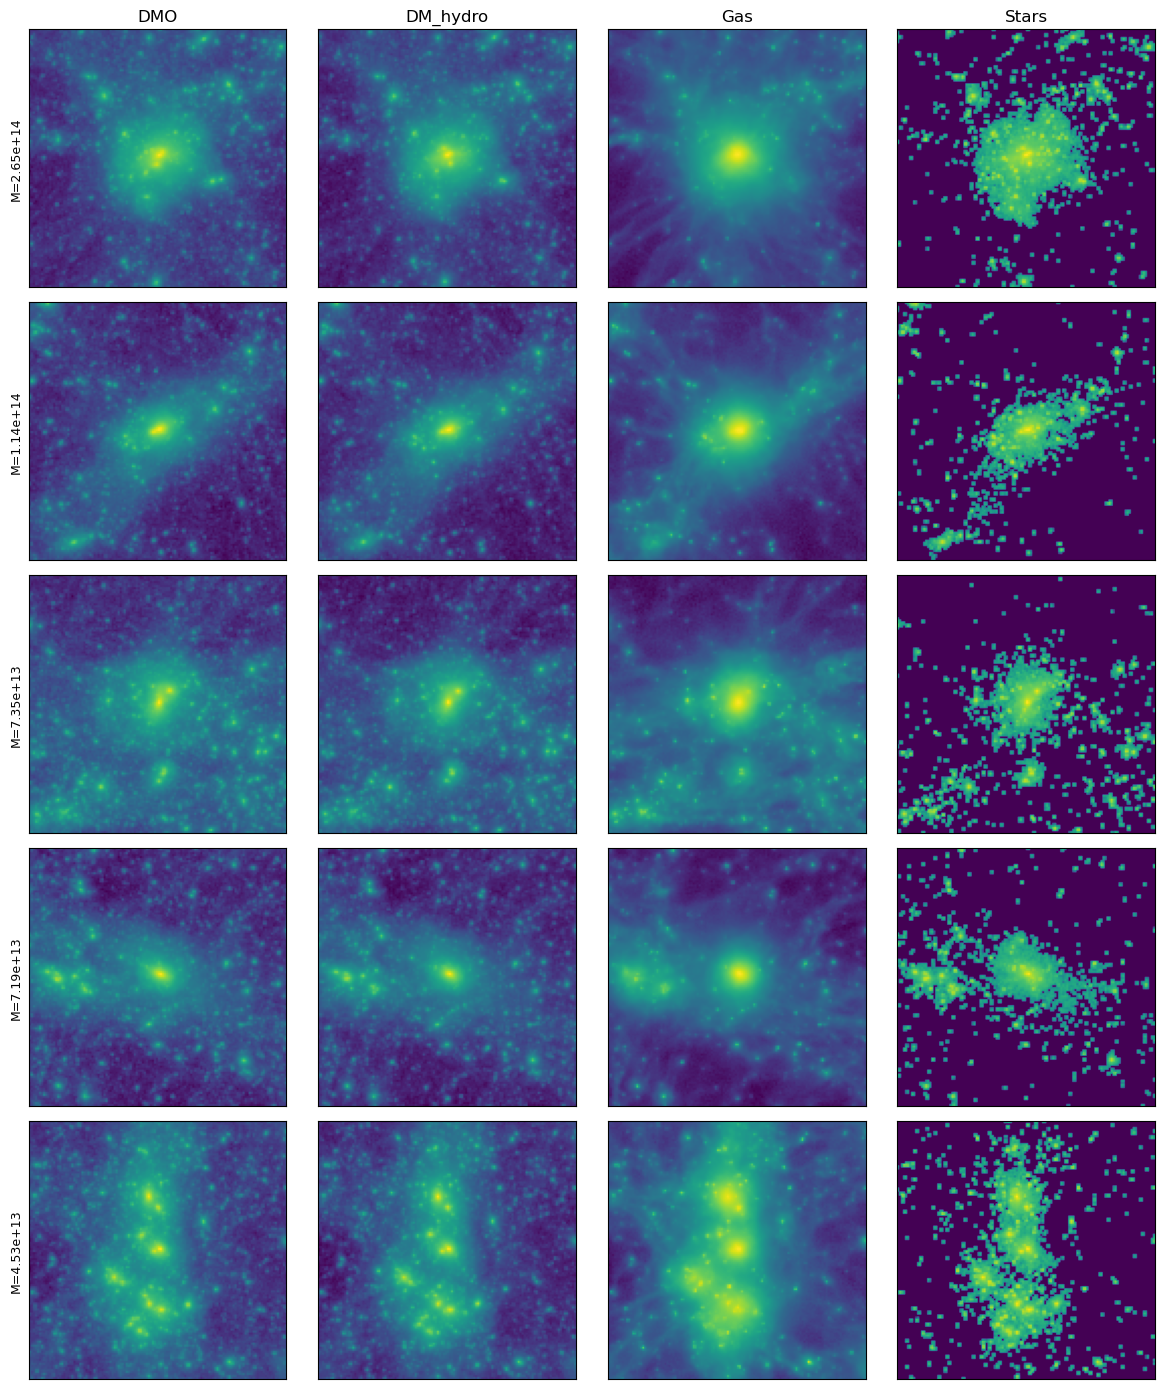

In [12]:
# Visualise the 5 most massive halos: DMO cutout vs generated hydro fields.
fig, axes = plt.subplots(5, 4, figsize=(12, 14))
for i in range(5):
    panels = [
        cutouts[i]["condition"],      # DMO conditioning patch (H, W)
        hydro_patches[i, 0],          # DM_hydro
        hydro_patches[i, 1],          # Gas
        hydro_patches[i, 2],          # Stars
    ]
    titles = ["DMO", "DM_hydro", "Gas", "Stars"] if i == 0 else [None] * 4
    for ax, img, t in zip(axes[i], panels, titles):
        ax.imshow(np.log10(1 + np.maximum(img, 0)), origin="lower")
        if t: ax.set_title(t)
        ax.set_xticks([]); ax.set_yticks([])
    axes[i, 0].set_ylabel(f"M={sim.halo_masses[top5[i]]:.2e}", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Cheat sheet

```python
# install + weights
pip install -e .
bind-download-weights fm_two_head

# python
import bind
sim    = bind.Simulation.from_paths(snapshot=..., group_catalog=..., halo_mass_min=1e13)
model  = bind.Model.from_local("weights/fm_two_head")
result = bind.paint(sim, model, params=my_35dim_vector, output_dir="bind_output/run1")

# CLI
bind-paint --snapshot ... --group_catalog ... --params ... --run_dir weights/fm_two_head --output_dir ...

# CAMELS suite (CV / 1P / SB35) batch evaluation
bind-camels-suite --suite cv --run_dir weights/fm_two_head --output_root ... [...CAMELS roots...]
```

That's the whole API. `Simulation`, `Model`, `paint`. Everything else (`extract_halo_cutouts`, the constants, the underlying `bind.inference.pipeline` primitives) is there if you need to build something different.
